In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from time import perf_counter

In [46]:
# Implement baseline algorithm

def baseline_max_sublist(arr):
    n = len(arr)
    max_so_far = -999999999999999
    for i in range(0,n):
        sum = 0
        for j in range(i,n):
            sum = arr[j] + sum
            if sum > max_so_far: 
                max_so_far = sum
    return max_so_far

arr = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
print(baseline_max_sublist(arr))

6


In [47]:
# Implement target algorithm

def kadane_max_sublist(arr):
    n = len(arr)
    max_so_far = -999999999999999
    current_max = 0
    for i in range(0,n):
        current_max = current_max + arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        elif current_max < 0:
            current_max = 0
    return max_so_far

arr = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
print(kadane_max_sublist(arr))

6


[40, -58, 45, 24, 79]
[[-38, -14, -12, -69, -26, -98, -38, 16, -71, 44, -65, -39, -28, -50, 81, -44, 16, -77, 50, 42, -33, 25, 63, -44, -13, -78, 45, 44, -80, -80, 88, 49, -18, -49, -51, -4, 16, -61, 30, 51, -60, 91, -38, 55, 96, -38, 99, -58, 32, -80, -14, -26, 56, 39, -3, -22, -13, 64, -41, -24, -7, -35, -21, -44, -22, 19, -1, 37, -13, 51, -91, -28, 88, 30, -71, 49, -48, 20, -93, -65, -71, -41, 34, 0, -30, 100, 4, -53, -91, 59, -61, 7, -18, -98, 42, 12, -23, -54, -55, 24], [-73, -31, 93, -6, 64, -42, -60, 8, 12, 6, 90, 100, -33, 50, 74, 18, -24, 86, 91, -50, -7, 7, 55, 71, 59, -87, 34, 64, 91, 55, 30, 13, -90, 61, 12, -9, 88, 98, 15, -85, 48, 10, -46, -14, 87, 45, 49, -51, -98, -86, 49, 40, 15, 47, -47, -44, -80, 80, 95, 24, -57, -75, -46, 98, -29, 80, 3, -90, -36, -94, -58, 59, -82, -59, -1, -42, 8, 23, 47, -26, 92, 37, 38, -7, -57, 57, -14, -15, -9, 85, 80, 88, -65, -28, 97, 98, 14, 98, 24, -38, -40, 55, -3, -87, 20, -73, -64, -93, -66, 63, -78, 61, 3, -74, -19, 20, -59, -31, -64, 

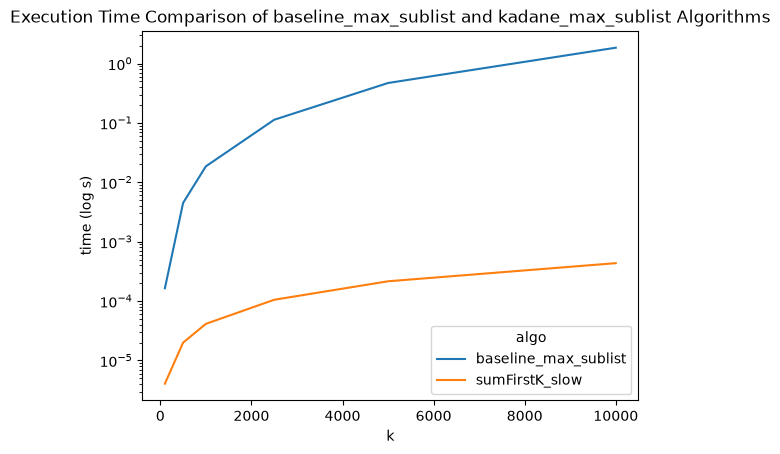

In [48]:
# helper function

def helper_function(n):
    random_array = []
    for i in range(n):
        random_array.append(np.random.randint(-100, 101))
    return random_array

print(helper_function(5))

# Function to benchmark the execution time of a given algorithm over a set of test cases

def benchmark_algo_multi(algo, test_cases, repeat=1):
    times = []
    for i in test_cases:
        total_duration = 0
        for _ in range(repeat):
            start = perf_counter()
            algo(i)
            end = perf_counter()
            duration = end - start
            total_duration += duration
        avg_time = total_duration / repeat
        times.append((len(i), avg_time))
    return times

# generates random lists of integers for testing
def test_cases(n):
    test_list = []
    for i in n:
        test_list.append(helper_function(i))
    return test_list

test_list = test_cases([100, 500, 1000, 2500, 5000, 10000])
print(test_list)

baseline_max_sublist_times = benchmark_algo_multi(baseline_max_sublist, test_list, repeat=10)
kadane_max_sublist_times = benchmark_algo_multi(kadane_max_sublist, test_list, repeat=10)

print(f"baseline:{baseline_max_sublist_times}")
print(f"kadane:{kadane_max_sublist_times}")

df_base = pd.DataFrame(baseline_max_sublist_times, columns = ["k", "time"])
df_base['algo'] = "baseline_max_sublist"

df_kadane = pd.DataFrame(kadane_max_sublist_times, columns = ["k", "time"])
df_kadane['algo'] = "sumFirstK_slow"

df = pd.concat([df_base, df_kadane], ignore_index=True)

sns.lineplot(data=df, x="k", y="time", hue="algo")
plt.xlabel("k")
plt.ylabel("time (log s)")
plt.title("Execution Time Comparison of baseline_max_sublist and kadane_max_sublist Algorithms")
plt.yscale("log")
plt.show()
